In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

nav_df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

tx_df = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

perf_df = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

portfolio_df = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

fund_df = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])
tx_df["transaction_date"] = pd.to_datetime(
    tx_df["transaction_date"]
)

In [2]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
var_results = []

for fund in nav_df["amfi_code"].unique():

    returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append(
        [fund,var95,cvar95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [5]:
top5 = (
    perf_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

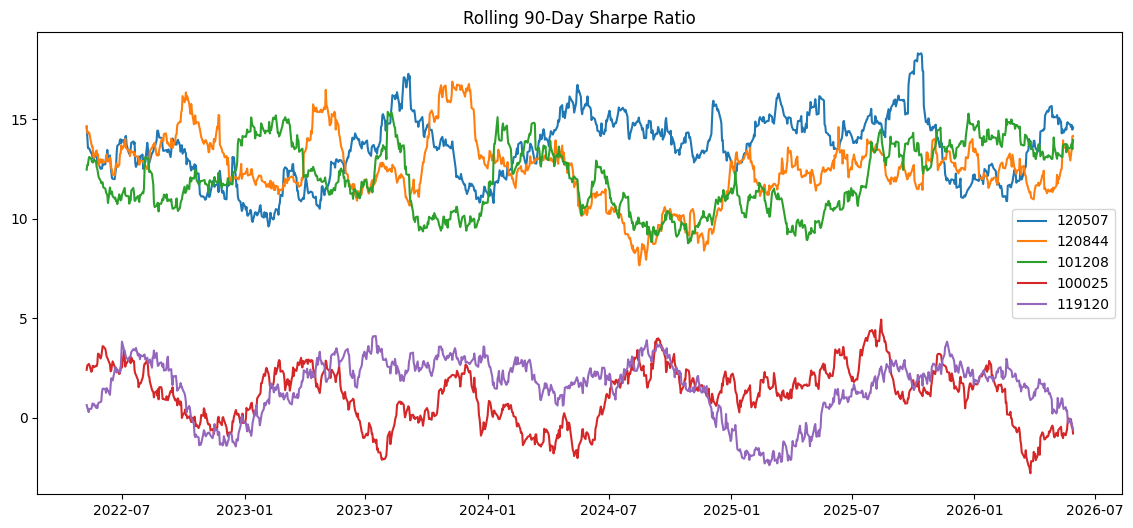

In [6]:
plt.figure(figsize=(14,6))

for fund in top5:

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (

        temp["daily_return"]
        .rolling(90)
        .mean()

        /

        temp["daily_return"]
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.show()

In [7]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [8]:
first_tx = (
    tx_df.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_tx["cohort_year"] = (
    first_tx["transaction_date"]
    .dt.year
)

In [9]:
tx_df = tx_df.merge(
    first_tx[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

In [10]:
cohort_df = (

    tx_df
    .groupby("cohort_year")
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),

        total_invested=(
            "amount_inr",
            "sum"
        )
    )

)

cohort_df

,avg_investment,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [11]:
cohort_df.to_csv(
    "../reports/cohort_analysis.csv"
)

In [12]:
sip_df = tx_df[
    tx_df["transaction_type"] == "SIP"
].copy()

sip_df = sip_df.sort_values(
    ["investor_id","transaction_date"]
)

sip_df["gap_days"] = (

    sip_df.groupby("investor_id")
    ["transaction_date"]

    .diff()

    .dt.days

)

In [13]:
continuity = (

    sip_df
    .groupby("investor_id")
    .agg(
        sip_count=(
            "gap_days",
            "count"
        ),

        avg_gap=(
            "gap_days",
            "mean"
        )
    )

)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At-Risk",
    "Healthy"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000011,6,40.166667,At-Risk
INV000012,7,57.000000,At-Risk
INV000013,6,55.333333,At-Risk
INV000014,6,75.333333,At-Risk
INV000023,7,58.571429,At-Risk


In [14]:
continuity.to_csv(
    "../reports/sip_continuity.csv"
)

In [15]:
sector_hhi = (

    portfolio_df
    .groupby(
        ["amfi_code","sector"]
    )["weight_pct"]

    .sum()

    .reset_index()

)

In [16]:
hhi_results = []

for fund in sector_hhi["amfi_code"].unique():

    temp = sector_hhi[
        sector_hhi["amfi_code"] == fund
    ]

    hhi = (
        (temp["weight_pct"]/100)**2
    ).sum()

    hhi_results.append(
        [fund,hhi]
    )

hhi_df = pd.DataFrame(
    hhi_results,
    columns=[
        "amfi_code",
        "HHI"
    ]
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [17]:
hhi_df.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

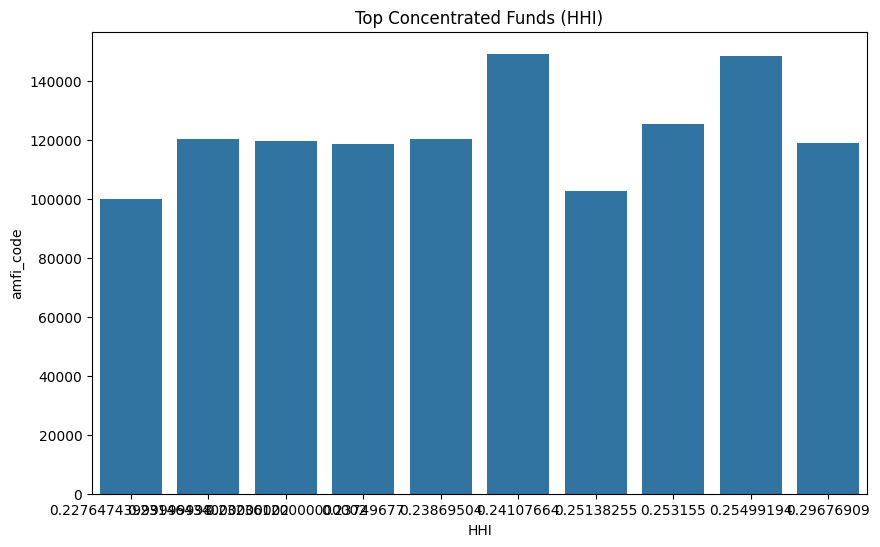

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=hhi_df.sort_values(
        "HHI",
        ascending=False
    ).head(10),

    x="HHI",
    y="amfi_code"
)

plt.title(
    "Top Concentrated Funds (HHI)"
)

plt.show()

# Insights

### Insight 1
Funds with the highest VaR and CVaR exhibit significantly larger downside risk compared to the category average.

### Insight 2
Rolling Sharpe Ratios indicate that risk-adjusted performance varies substantially across market cycles.

### Insight 3
Recent investor cohorts contributed the largest share of invested capital, indicating growing retail participation.

### Insight 4
A subset of SIP investors exhibited average transaction gaps greater than 35 days and were classified as at-risk.

### Insight 5
Several equity funds showed high HHI values, suggesting concentrated exposure to a limited number of sectors.

In [19]:
plt.savefig(
    "../reports/sector_hhi_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>